In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.impute import MissingIndicator,SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report, average_precision_score, precision_recall_curve
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [5]:
dataset = pd.read_csv("Fraud")

In [7]:
df = pd.DataFrame(dataset)

In [9]:
df_scoped = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

# Does 'M' ever appear as a destination prefix in this subset?
print(df_scoped['nameDest'].str[0].value_counts())

nameDest
C    2770409
Name: count, dtype: int64


In [11]:
df_scoped

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0
19,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


In [12]:
print(pd.crosstab(df['type'], df['isFraud']))

# 2. Sanity check as a percentage — should show 0.00% fraud for PAYMENT/CASH_IN/DEBIT
print(df.groupby('type')['isFraud'].mean() * 100)

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097
type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64


In [16]:
df_scoped.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [18]:
df_scoped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2770409 entries, 2 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 253.6+ MB


In [11]:
print("Memory Before:",
      df_scoped.memory_usage(deep=True).sum()/1024**2,"MB")

df_scoped['type']=df_scoped['type'].astype('category')

print("Memory After:",
      df_scoped.memory_usage(deep=True).sum()/1024**2,"MB")

Memory Before: 655.1365098953247 MB
Memory After: 507.1809186935425 MB


C:\Users\hp\AppData\Local\Temp\ipykernel_21332\1644350336.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_scoped['type']=df_scoped['type'].astype('category')


In [15]:
duplicates=df_scoped.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [17]:
fraud=df_scoped['isFraud'].value_counts()

print(fraud)

print()

print(df_scoped['isFraud'].value_counts(normalize=True)*100)

isFraud
0    2762196
1       8213
Name: count, dtype: int64

isFraud
0    99.703546
1     0.296454
Name: proportion, dtype: float64


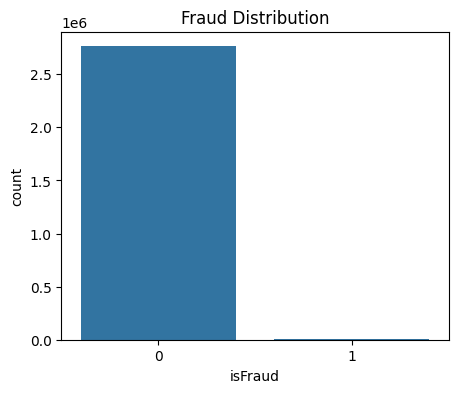

In [19]:
plt.figure(figsize=(5,4))

sns.countplot(data=df_scoped,
              x='isFraud')

plt.title("Fraud Distribution")
plt.show()

In [21]:
type_fraud=pd.crosstab(df_scoped['type'],
                       df_scoped['isFraud'],
                       margins=True)

type_fraud

isFraud,0,1,All
type,,,
CASH_OUT,2233384,4116,2237500
TRANSFER,528812,4097,532909
All,2762196,8213,2770409


In [25]:
type_percentage=pd.crosstab(
    df_scoped['type'],
    df_scoped['isFraud'],
    normalize='index'
)*100

type_percentage

isFraud,0,1
type,,
CASH_OUT,99.816045,0.183955
TRANSFER,99.231201,0.768799


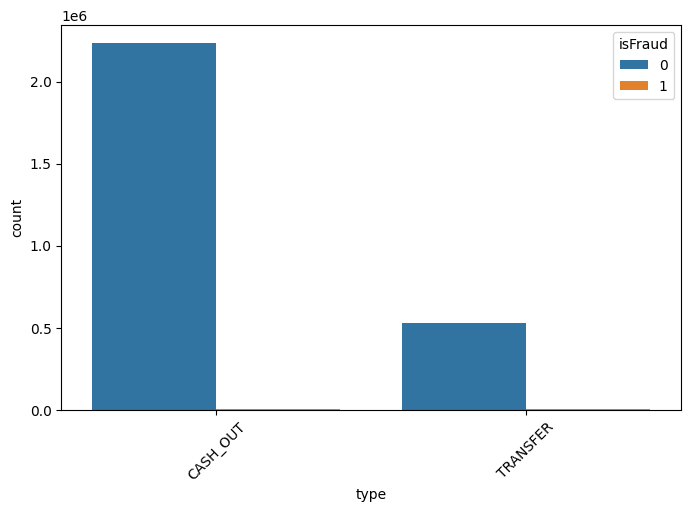

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_scoped,
              x='type',
              hue='isFraud')

plt.xticks(rotation=45)

plt.show()

In [29]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

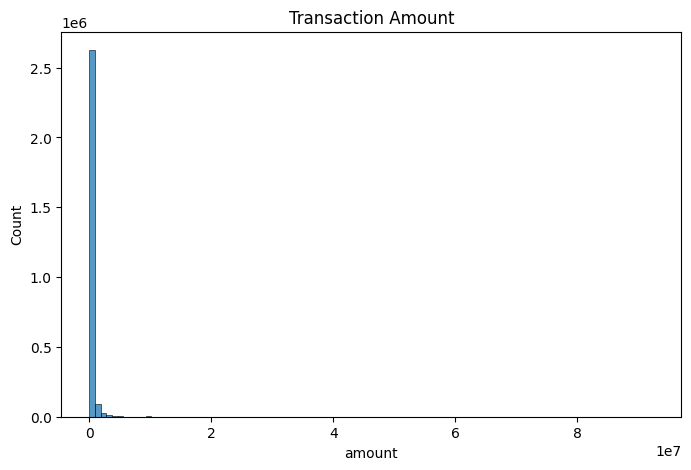

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df_scoped['amount'],
             bins=100)

plt.title("Transaction Amount")

plt.show()

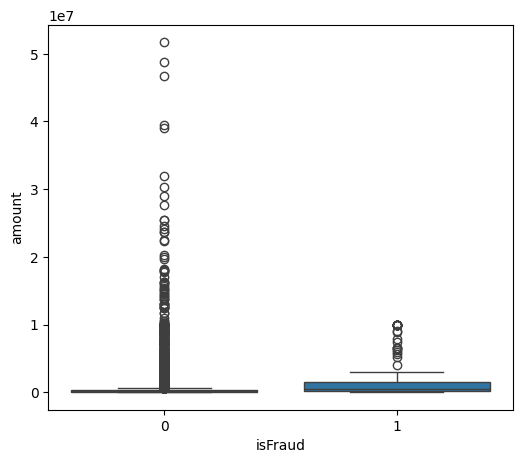

In [33]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='isFraud',
    y='amount',
    data=df_scoped.sample(70000,random_state=42)
)

plt.show()

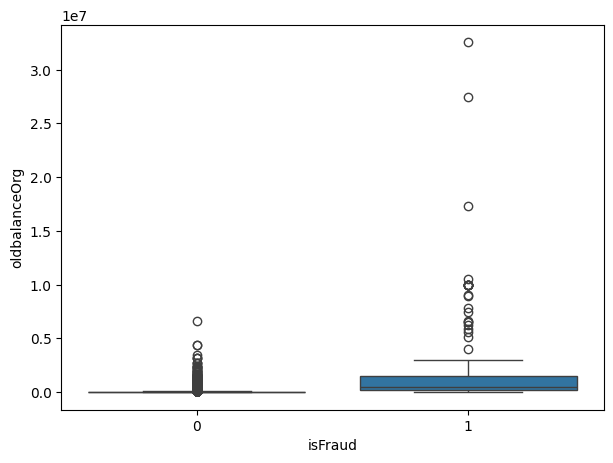

In [39]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_scoped.sample(70000,random_state=42),
    x='isFraud',
    y='oldbalanceOrg'
)

plt.show()

In [45]:
numeric=df_scoped.select_dtypes(include=np.number)

corr=numeric.corr()

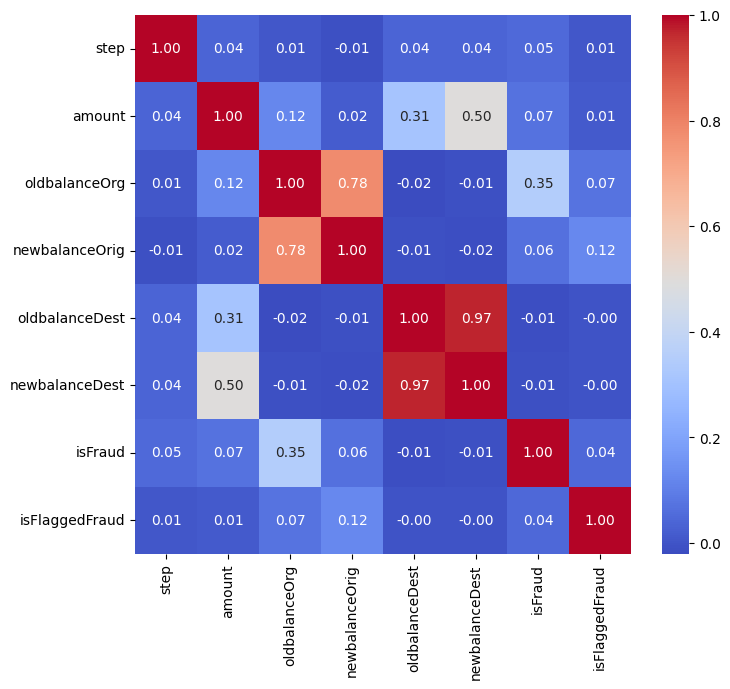

In [61]:
plt.figure(figsize=(8,7))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.show()

In [51]:
print(df_scoped['nameOrig'].nunique())
print(df_scoped['nameDest'].nunique())

2768630
509565


In [57]:
numerical_cols = df_scoped.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target
numerical_features = [col for col in numerical_cols
                      if col not in ['isFraud', 'isFlaggedFraud','step']]

print("Numerical Features:")
print(numerical_features)

Numerical Features:
['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']


In [59]:
summary = df_scoped[numerical_features].describe().T

summary['median'] = df_scoped[numerical_features].median()

summary['skewness'] = df_scoped[numerical_features].skew()

summary['kurtosis'] = df_scoped[numerical_features].kurt()

summary['missing_%'] = df_scoped[numerical_features].isnull().mean()*100

summary

,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis,missing_%
amount,2770409.0,3.175361e+05,8.877897e+05,0.0,82973.54,171260.93,306791.18,9.244552e+07,171260.93,21.934943,868.557434,0.0
oldbalanceOrg,2770409.0,4.764308e+04,2.513251e+05,0.0,0.00,303.96,30997.00,5.958504e+07,303.96,70.011751,9402.888430,0.0
newbalanceOrig,2770409.0,1.609190e+04,1.512558e+05,0.0,0.00,0.00,0.00,4.958504e+07,0.00,127.319556,27926.052970,0.0
oldbalanceDest,2770409.0,1.703551e+06,4.225550e+06,0.0,128073.45,555709.97,1735900.15,3.560159e+08,555709.97,17.160181,668.813069,0.0
newbalanceDest,2770409.0,2.049734e+06,4.676990e+06,0.0,327289.08,828053.88,2122198.45,3.561793e+08,828053.88,16.433847,585.026978,0.0


In [17]:
numerical_features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

In [29]:
sample_df = df_scoped[numerical_features].sample(
    n=50000,
    random_state=42
)

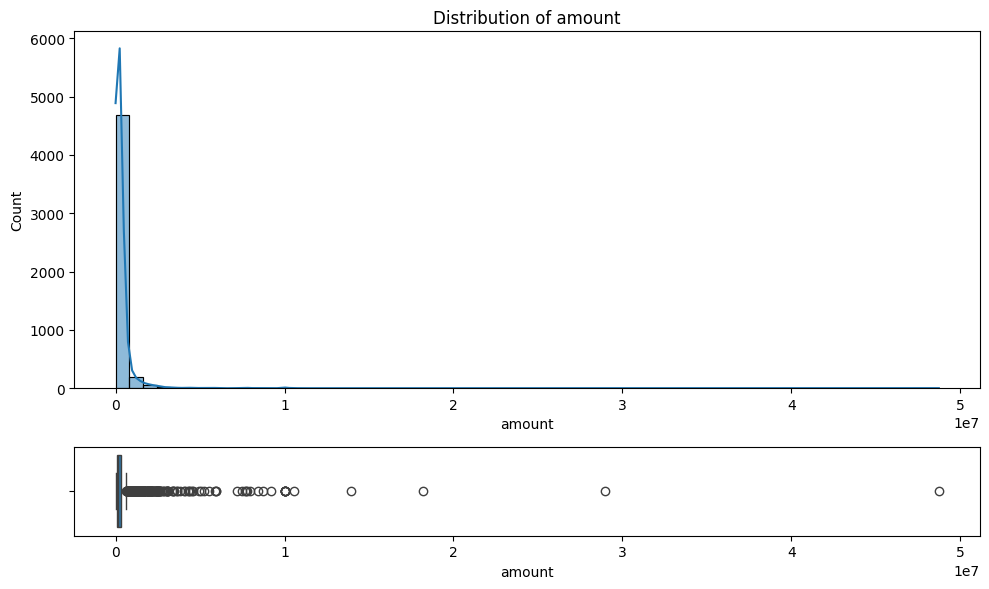

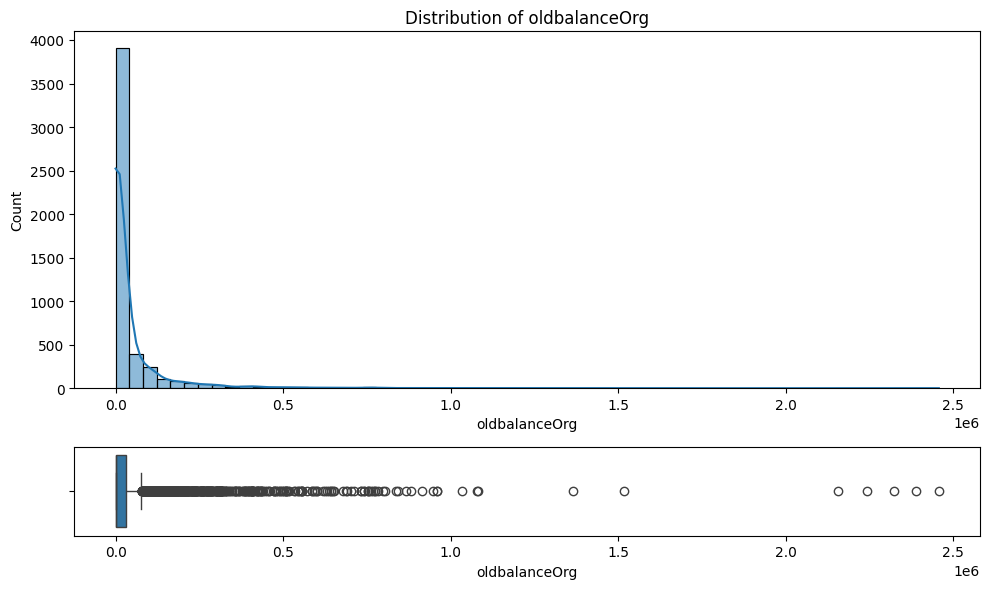

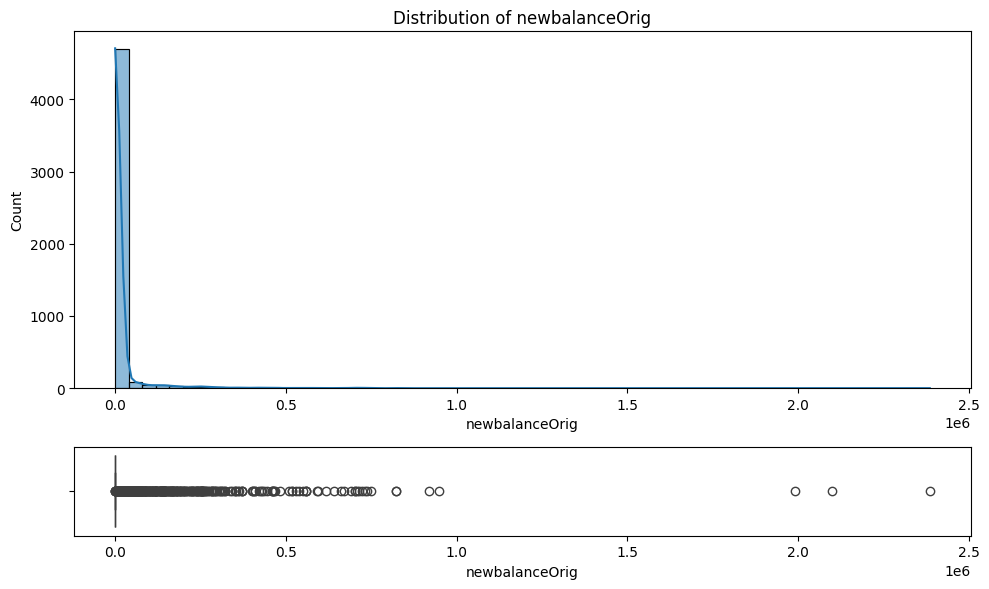

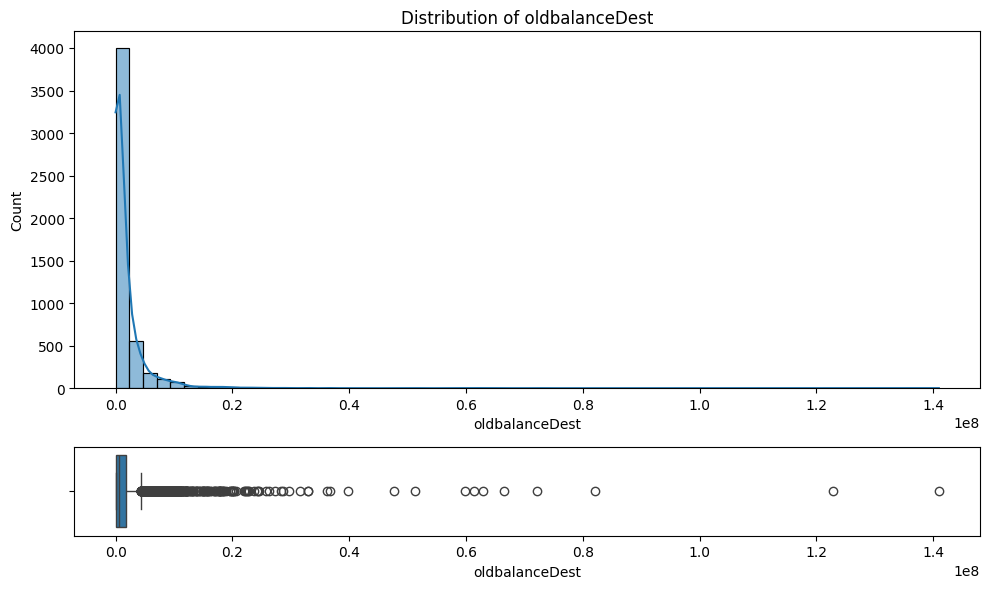

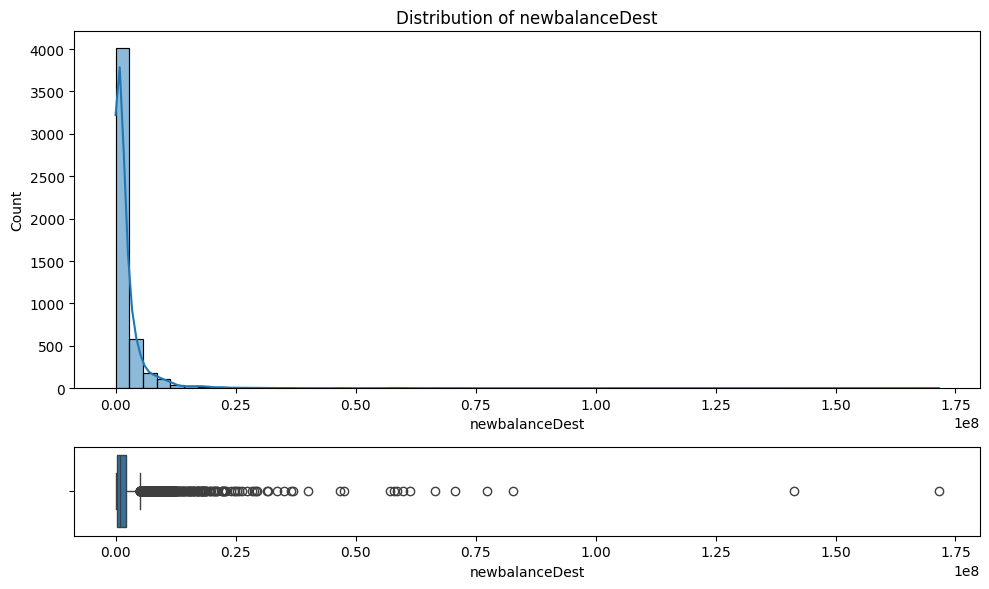

In [25]:
for feature in numerical_features:

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10,6),
        gridspec_kw={'height_ratios':[4,1]}
    )

    sns.histplot(
        sample_df[feature],
        bins=60,
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title(f"Distribution of {feature}")

    sns.boxplot(
        x=sample_df[feature],
        ax=axes[1]
    )

    plt.tight_layout()
    plt.show()

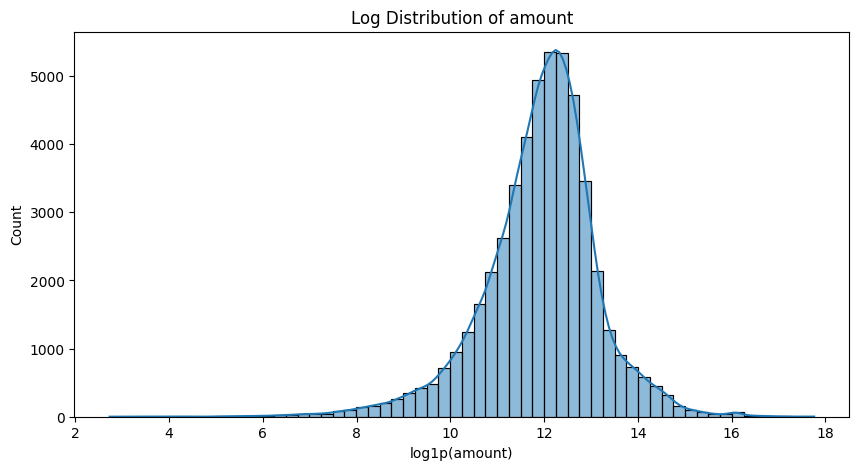

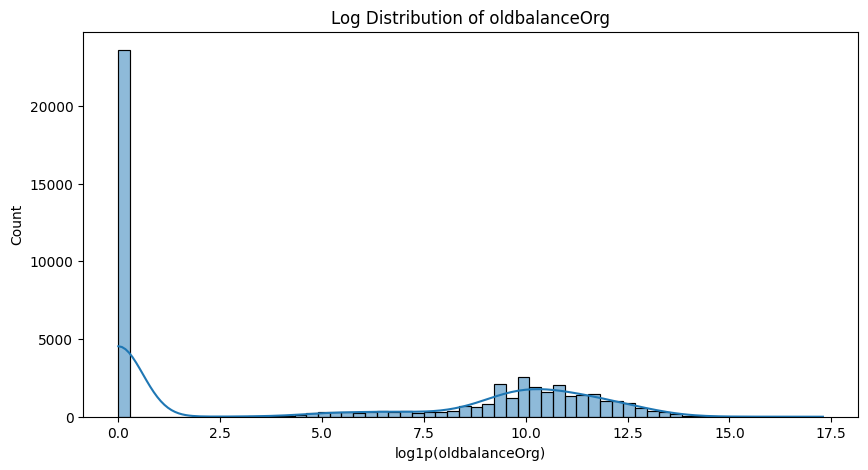

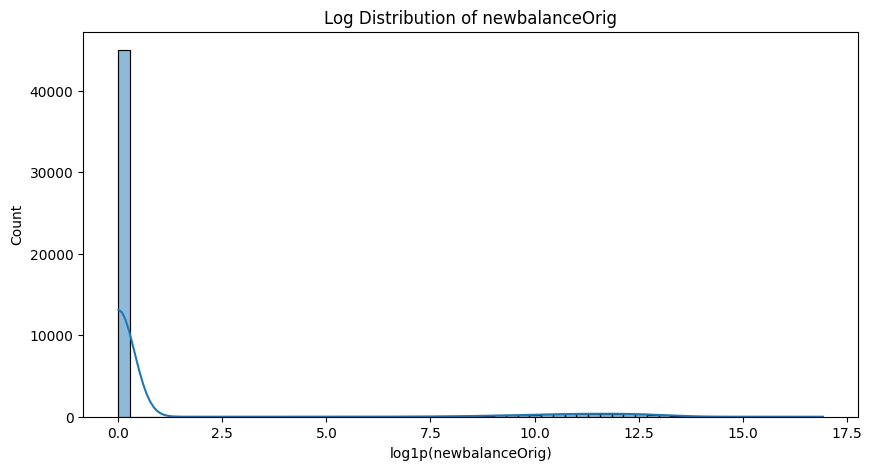

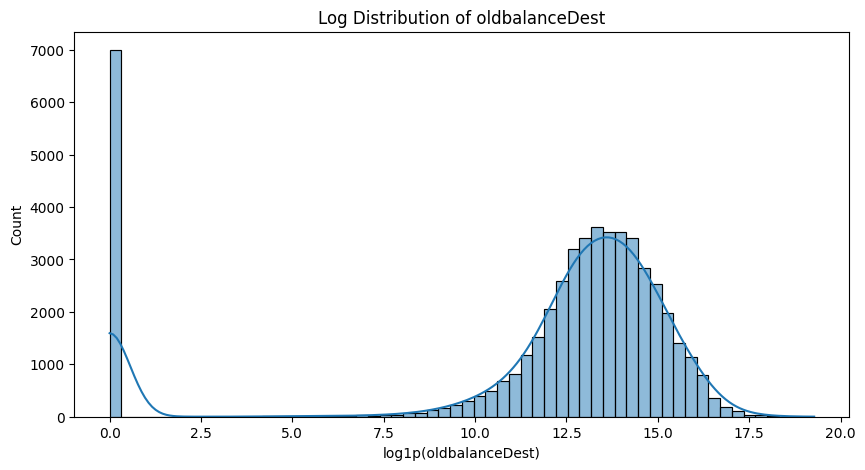

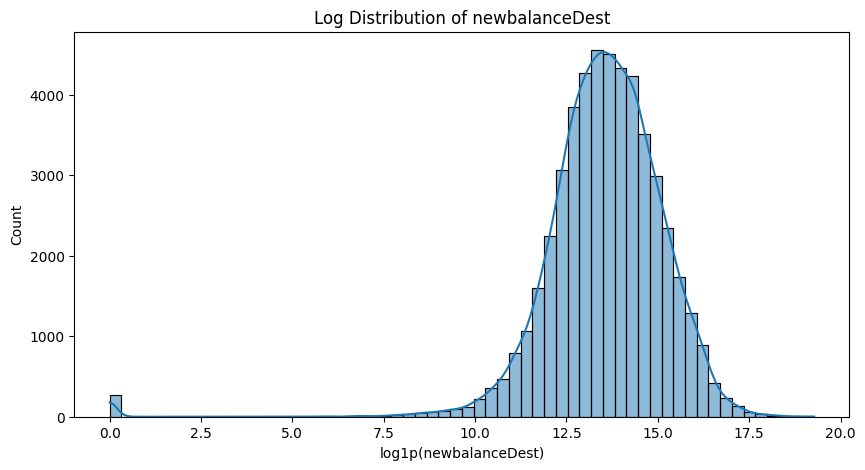

In [31]:
for feature in numerical_features:

    plt.figure(figsize=(10,5))

    sns.histplot(
        np.log1p(sample_df[feature]),
        bins=60,
        kde=True
    )

    plt.title(f"Log Distribution of {feature}")

    plt.xlabel(f"log1p({feature})")

    plt.show()

In [33]:
numerical_features = [
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

In [37]:
df1 = df_scoped

In [43]:
for col in numerical_features:
    df1[f'log_{col}'] = np.log1p(df1[col])

df1.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_25448\2676993887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[f'log_{col}'] = np.log1p(df1[col])
C:\Users\hp\AppData\Local\Temp\ipykernel_25448\2676993887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[f'log_{col}'] = np.log1p(df1[col])
C:\Users\hp\AppData\Local\Temp\ipykernel_25448\2676993887.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,log_oldbalanceOrg,log_newbalanceOrig,log_oldbalanceDest,log_newbalanceDest
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,5.204007,5.204007,0.0,0.000000,0.000000
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,5.204007,5.204007,0.0,9.960954,0.000000
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,12.342066,9.637306,0.0,8.533854,10.849617
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,12.279840,6.559615,0.0,10.017976,0.000000
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,12.649754,9.290629,0.0,8.743213,14.815839


In [47]:
comparison = pd.DataFrame({
    "Original Skewness": df_scoped[numerical_features].skew(),
    "Log Skewness": df1[[f'log_{c}' for c in numerical_features]].skew().values
})

comparison

,Original Skewness,Log Skewness
amount,21.934943,-0.698890
oldbalanceOrg,70.011751,0.094176
newbalanceOrig,127.319556,2.787288
oldbalanceDest,17.160181,-1.703464
newbalanceDest,16.433847,-2.823009


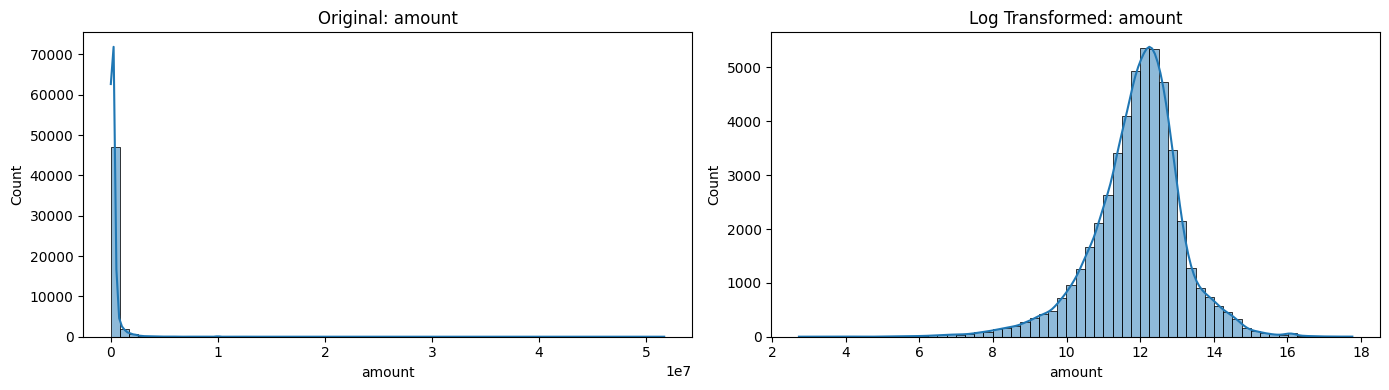

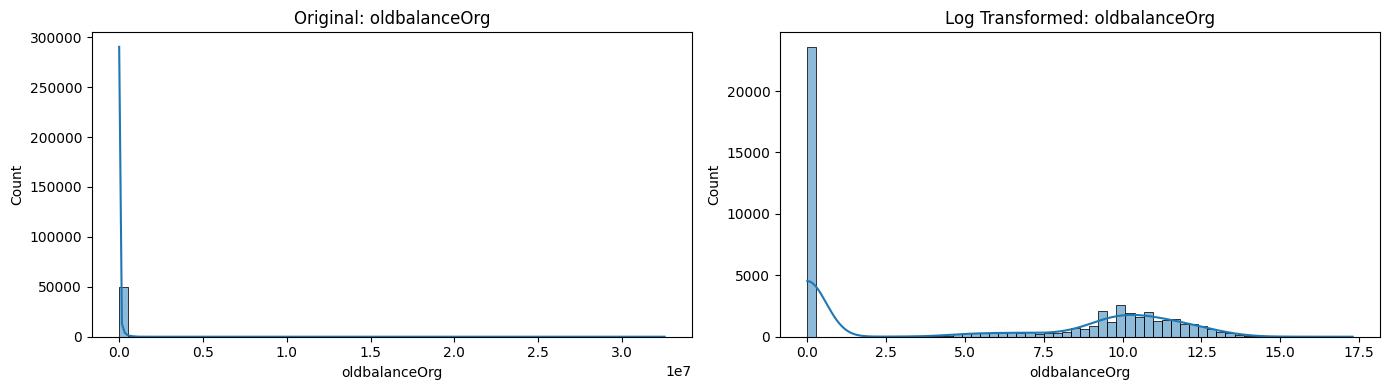

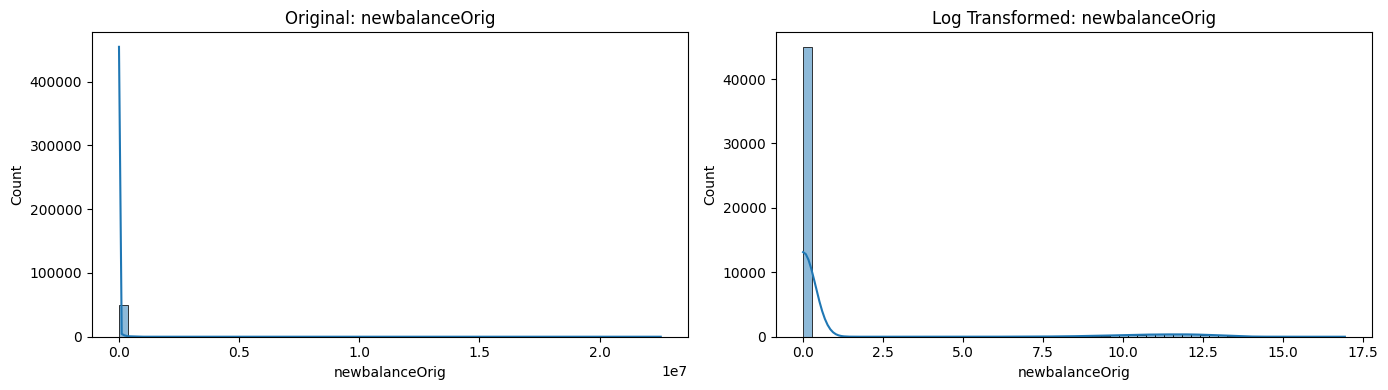

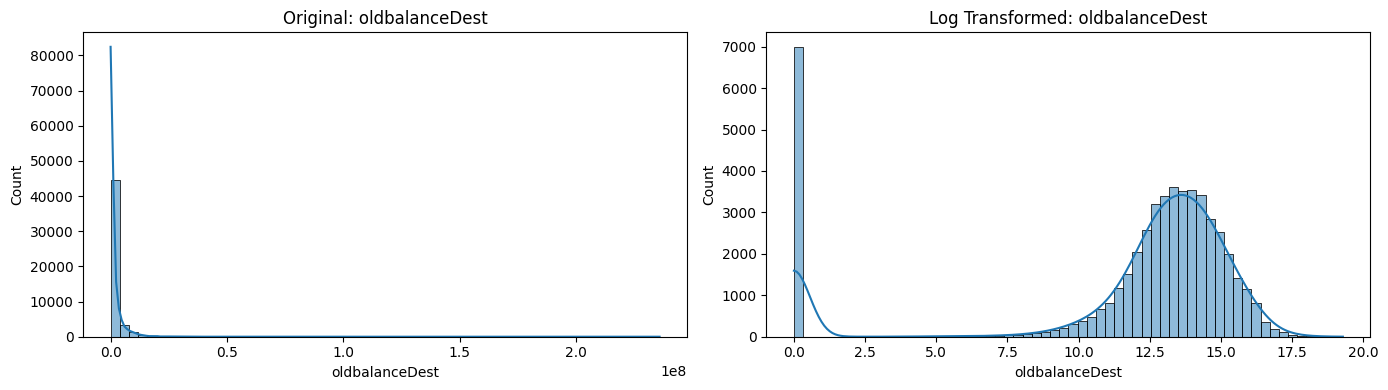

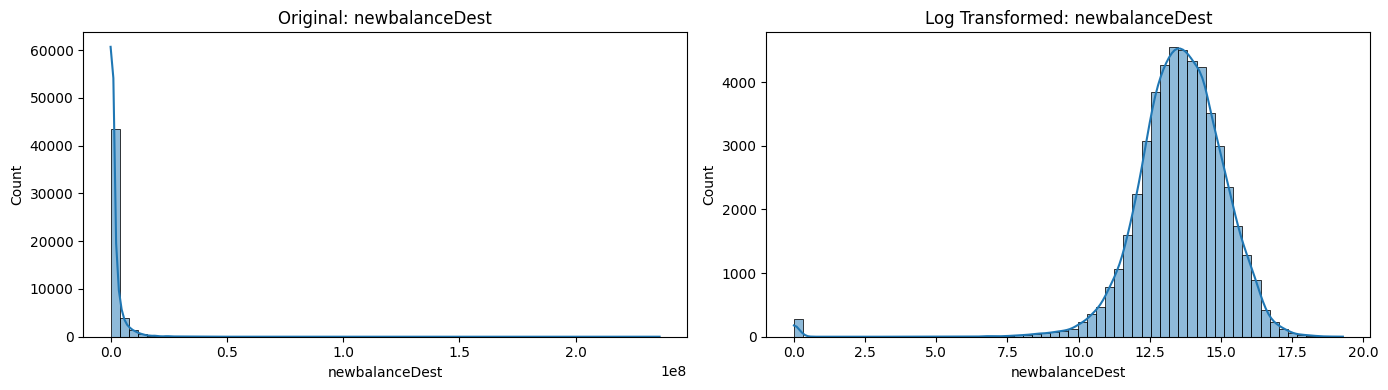

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sample = df1.sample(50000, random_state=42)

for col in numerical_features:

    fig, axes = plt.subplots(1, 2, figsize=(14,4))

    sns.histplot(sample[col],
                 bins=60,
                 kde=True,
                 ax=axes[0])

    axes[0].set_title(f"Original: {col}")

    sns.histplot(np.log1p(sample[col]),
                 bins=60,
                 kde=True,
                 ax=axes[1])

    axes[1].set_title(f"Log Transformed: {col}")

    plt.tight_layout()
    plt.show()

## As some columns become neagtive skewed , so we keep as raw , we only do log transformation on amount and oldbalanceOrg.

In [13]:
df3 = df_scoped

In [15]:
log_features = [
    "amount",
    "oldbalanceOrg"
]

for col in log_features:
    df3[f"log_{col}"] = np.log1p(df3[col])

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\2788647624.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3[f"log_{col}"] = np.log1p(df3[col])
C:\Users\hp\AppData\Local\Temp\ipykernel_21332\2788647624.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3[f"log_{col}"] = np.log1p(df3[col])


## Feature Engineering

In [17]:
df3["sender_balance_change"] = (
    df3["oldbalanceOrg"] -
    df3["newbalanceOrig"]
)

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\3286419147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["sender_balance_change"] = (


In [19]:
df3["receiver_balance_change"] = (
    df3["newbalanceDest"] -
    df3["oldbalanceDest"]
)

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\2227244735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["receiver_balance_change"] = (


In [21]:
df3["amount_sender_ratio"] = (
    df3["amount"] /
    (df3["oldbalanceOrg"] + 1)
)

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\303997947.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["amount_sender_ratio"] = (


In [23]:
df3["sender_error"] = (
    df3["oldbalanceOrg"] -
    df3["amount"] -
    df3["newbalanceOrig"]
)

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\2658246986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["sender_error"] = (


In [25]:
df3["receiver_error"] = (
    df3["oldbalanceDest"] +
    df3["amount"] -
    df3["newbalanceDest"]
)

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\2193956043.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["receiver_error"] = (


In [27]:
df3["emptied_account"] = (
    df3["newbalanceOrig"] == 0
).astype(int)

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\2334359448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["emptied_account"] = (


In [29]:
df3["dest_balance_missing"] = (
    (df3["oldbalanceDest"] == 0) &
    (df3["newbalanceDest"] == 0)
).astype(int)

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\2581964167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3["dest_balance_missing"] = (


In [75]:
engineered = [
    "sender_balance_change",
    "receiver_balance_change",
    "amount_sender_ratio",
    "sender_error",
    "receiver_error"
]

df3[engineered].describe()

,sender_balance_change,receiver_balance_change,amount_sender_ratio,sender_error,receiver_error
count,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06,2.770409e+06
mean,3.155117e+04,3.461833e+05,1.577019e+05,-2.859850e+05,-2.864713e+04
std,1.637969e+05,1.177786e+06,7.615423e+05,8.753230e+05,5.934794e+05
min,-2.657526e+04,-9.681485e+06,0.000000e+00,-9.244552e+07,-7.588573e+07
25%,0.000000e+00,8.153918e+04,4.993073e+00,-2.798912e+05,0.000000e+00
50%,2.960000e+02,1.752876e+05,5.607207e+02,-1.435971e+05,0.000000e+00
75%,2.669609e+04,3.233030e+05,1.567414e+05,-5.185310e+04,0.000000e+00
max,1.000000e+07,1.056878e+08,9.244552e+07,1.000000e-02,1.000000e+07


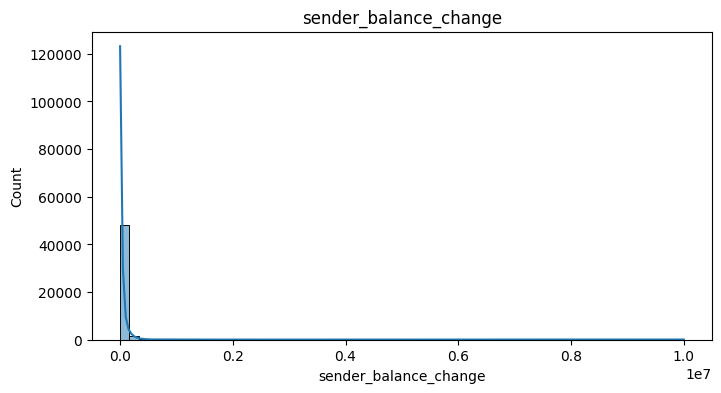

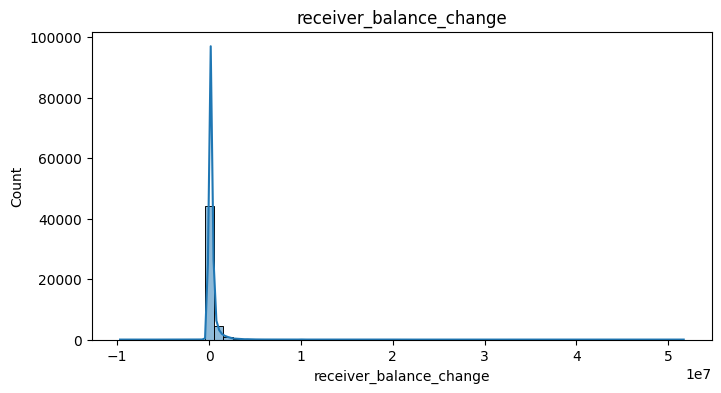

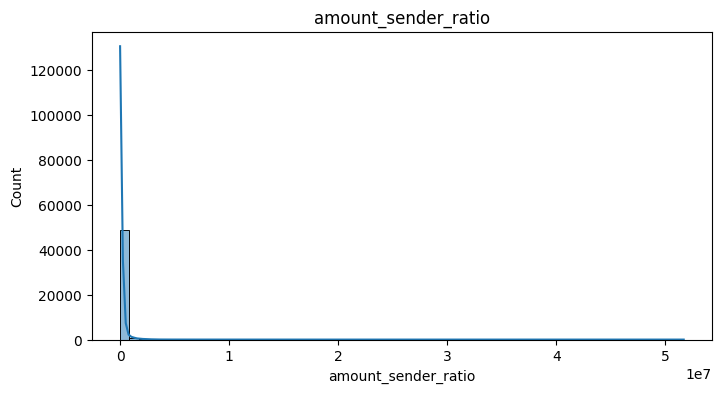

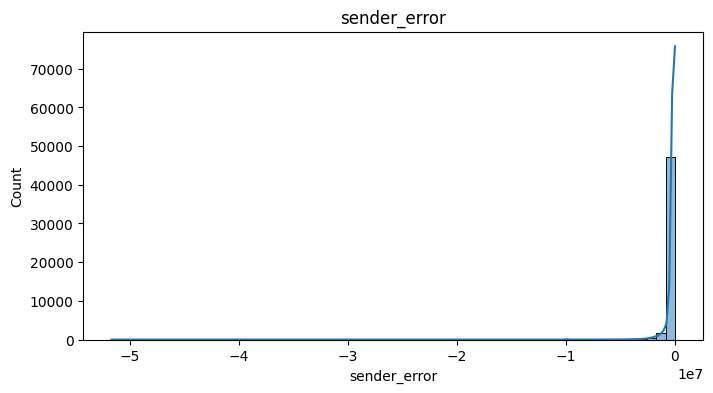

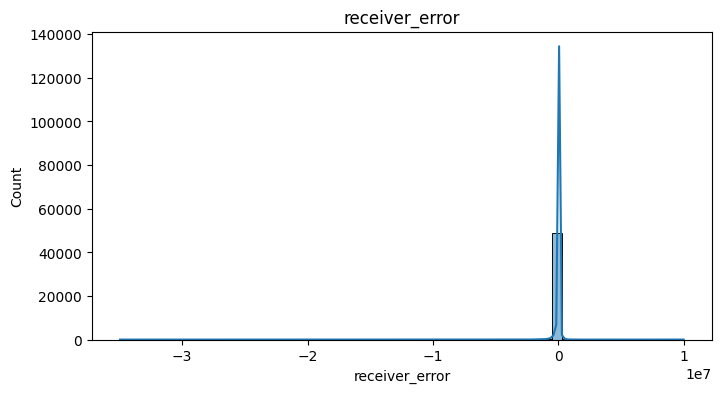

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

sample = df3.sample(50000, random_state=42)

for col in engineered:
    plt.figure(figsize=(8, 4))
    sns.histplot(sample[col], bins=60, kde=True)
    plt.title(col)
    plt.show()

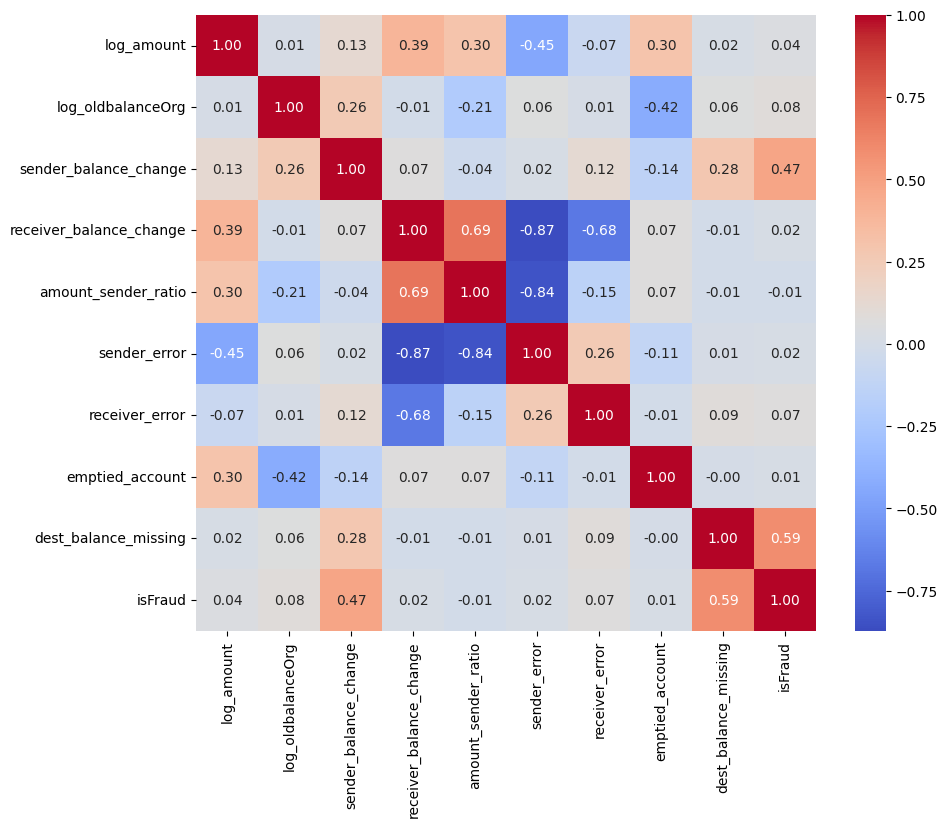

In [79]:
new_features = [
    "log_amount",
    "log_oldbalanceOrg",
    "sender_balance_change",
    "receiver_balance_change",
    "amount_sender_ratio",
    "sender_error",
    "receiver_error",
    "emptied_account",
    "dest_balance_missing"
]

corr = df3[new_features + ["isFraud"]].corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [83]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2770409 entries, 2 to 6362619
Data columns (total 23 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   step                     int64   
 1   type                     category
 2   amount                   float64 
 3   nameOrig                 object  
 4   oldbalanceOrg            float64 
 5   newbalanceOrig           float64 
 6   nameDest                 object  
 7   oldbalanceDest           float64 
 8   newbalanceDest           float64 
 9   isFraud                  int64   
 10  isFlaggedFraud           int64   
 11  log_amount               float64 
 12  log_oldbalanceOrg        float64 
 13  log_newbalanceOrig       float64 
 14  log_oldbalanceDest       float64 
 15  log_newbalanceDest       float64 
 16  sender_balance_change    float64 
 17  receiver_balance_change  float64 
 18  amount_sender_ratio      float64 
 19  sender_error             float64 
 20  receiver_error           floa

In [31]:
df3

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,log_oldbalanceOrg,sender_balance_change,receiver_balance_change,amount_sender_ratio,sender_error,receiver_error,emptied_account,dest_balance_missing
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,5.204007,5.204007,181.00,0.00,0.994505,0.00,1.810000e+02,1,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,5.204007,5.204007,181.00,-21182.00,0.994505,0.00,2.136300e+04,1,0
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,12.342066,9.637306,15325.00,46430.44,14.950668,-213808.94,1.827035e+05,1,0
19,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,12.279840,6.559615,705.00,-22425.00,304.972096,-214605.30,2.377353e+05,1,0
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,12.649754,9.290629,10835.00,2712905.89,28.763925,-300850.89,-2.401220e+06,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,12.735768,12.735768,339682.13,339682.13,0.999997,0.00,0.000000e+00,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,15.657870,15.657870,6311409.28,0.00,1.000000,0.00,6.311409e+06,1,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,15.657870,15.657870,6311409.28,6311409.27,1.000000,0.00,1.000000e-02,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,13.652996,13.652996,850002.52,0.00,0.999999,0.00,8.500025e+05,1,1


In [85]:
cols_to_drop = [
    'log_newbalanceOrig',
    'log_oldbalanceDest',
    'log_newbalanceDest'
]

df3.drop(columns=cols_to_drop, inplace=True, errors='ignore')

C:\Users\hp\AppData\Local\Temp\ipykernel_25448\413967111.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.drop(columns=cols_to_drop, inplace=True, errors='ignore')


In [87]:
df3

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,log_oldbalanceOrg,sender_balance_change,receiver_balance_change,amount_sender_ratio,sender_error,receiver_error,emptied_account,dest_balance_missing
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,5.204007,5.204007,181.00,0.00,0.994505,0.00,1.810000e+02,1,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,5.204007,5.204007,181.00,-21182.00,0.994505,0.00,2.136300e+04,1,0
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,12.342066,9.637306,15325.00,46430.44,14.950668,-213808.94,1.827035e+05,1,0
19,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,12.279840,6.559615,705.00,-22425.00,304.972096,-214605.30,2.377353e+05,1,0
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,12.649754,9.290629,10835.00,2712905.89,28.763925,-300850.89,-2.401220e+06,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,12.735768,12.735768,339682.13,339682.13,0.999997,0.00,0.000000e+00,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,15.657870,15.657870,6311409.28,0.00,1.000000,0.00,6.311409e+06,1,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,15.657870,15.657870,6311409.28,6311409.27,1.000000,0.00,1.000000e-02,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,13.652996,13.652996,850002.52,0.00,0.999999,0.00,8.500025e+05,1,1


In [33]:

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

# One-Hot Encode
encoded = ohe.fit_transform(df3[['type']])

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['type']),
    index=df3.index
)

# Remove original column
df3.drop(columns='type', inplace=True)

# Add encoded columns
df3 = pd.concat([df3, encoded_df], axis=1)

C:\Users\hp\AppData\Local\Temp\ipykernel_21332\1642727727.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3.drop(columns='type', inplace=True)


In [49]:
df3.drop(columns=["nameOrig"], inplace = True)

In [53]:
df3.drop(columns=["nameDest"], inplace = True)

In [57]:
df3.drop(columns=["step"], inplace = True)

## Feature selection

In [59]:
df3

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,log_oldbalanceOrg,sender_balance_change,receiver_balance_change,amount_sender_ratio,sender_error,receiver_error,emptied_account,dest_balance_missing,type_CASH_OUT,type_TRANSFER
2,181.00,181.00,0.0,0.00,0.00,1,0,5.204007,5.204007,181.00,0.00,0.994505,0.00,1.810000e+02,1,1,0.0,1.0
3,181.00,181.00,0.0,21182.00,0.00,1,0,5.204007,5.204007,181.00,-21182.00,0.994505,0.00,2.136300e+04,1,0,1.0,0.0
15,229133.94,15325.00,0.0,5083.00,51513.44,0,0,12.342066,9.637306,15325.00,46430.44,14.950668,-213808.94,1.827035e+05,1,0,1.0,0.0
19,215310.30,705.00,0.0,22425.00,0.00,0,0,12.279840,6.559615,705.00,-22425.00,304.972096,-214605.30,2.377353e+05,1,0,0.0,1.0
24,311685.89,10835.00,0.0,6267.00,2719172.89,0,0,12.649754,9.290629,10835.00,2712905.89,28.763925,-300850.89,-2.401220e+06,1,0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,339682.13,339682.13,0.0,0.00,339682.13,1,0,12.735768,12.735768,339682.13,339682.13,0.999997,0.00,0.000000e+00,1,0,1.0,0.0
6362616,6311409.28,6311409.28,0.0,0.00,0.00,1,0,15.657870,15.657870,6311409.28,0.00,1.000000,0.00,6.311409e+06,1,1,0.0,1.0
6362617,6311409.28,6311409.28,0.0,68488.84,6379898.11,1,0,15.657870,15.657870,6311409.28,6311409.27,1.000000,0.00,1.000000e-02,1,0,1.0,0.0
6362618,850002.52,850002.52,0.0,0.00,0.00,1,0,13.652996,13.652996,850002.52,0.00,0.999999,0.00,8.500025e+05,1,1,0.0,1.0


In [61]:
X = df3.drop(columns=["isFraud"])
y = df3["isFraud"]

print(X.shape)

(2770409, 17)


In [161]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)

X_constant = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]

X = X[selected_columns]

print(X.shape)

(2770409, 18)


In [163]:
duplicate_columns = []

for i in range(len(X.columns)):
    col1 = X.columns[i]

    for j in range(i + 1, len(X.columns)):
        col2 = X.columns[j]

        if X[col1].equals(X[col2]):
            duplicate_columns.append(col2)

duplicate_columns

[]

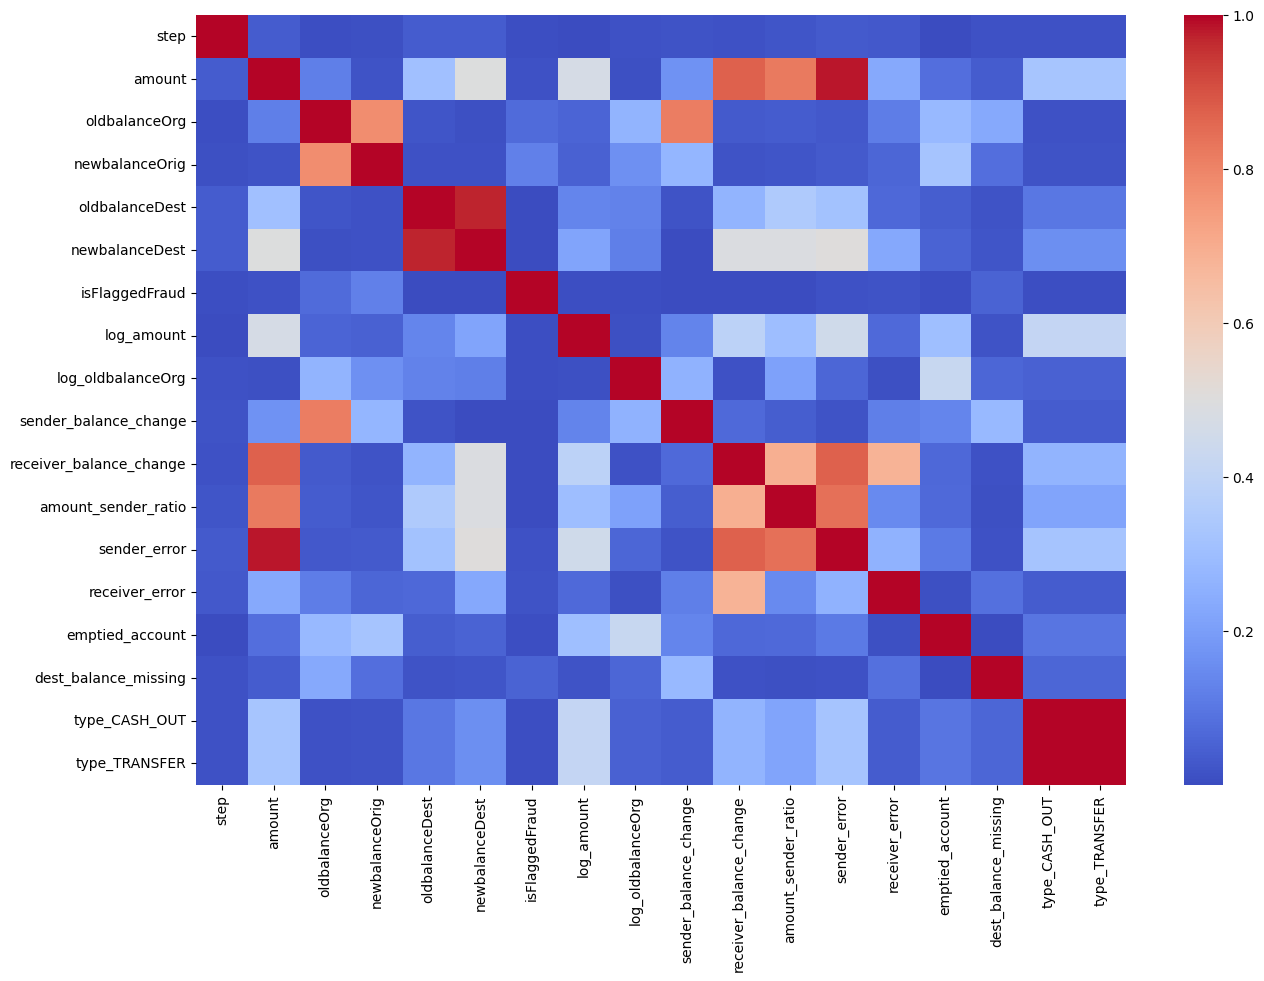

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr().abs()

plt.figure(figsize=(15,10))

sns.heatmap(corr,
            cmap="coolwarm")

plt.show()

In [179]:
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.90)
]

print(to_drop)

['newbalanceDest', 'sender_error', 'type_TRANSFER']


In [181]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False)

newbalanceOrig             0.145367
amount_sender_ratio        0.139380
dest_balance_missing       0.133268
emptied_account            0.109773
sender_balance_change      0.108599
type_CASH_OUT              0.045356
type_TRANSFER              0.045257
sender_error               0.043328
oldbalanceOrg              0.038896
log_oldbalanceOrg          0.034196
newbalanceDest             0.031910
receiver_balance_change    0.030748
step                       0.022360
receiver_error             0.019177
amount                     0.017475
oldbalanceDest             0.017401
log_amount                 0.017276
isFlaggedFraud             0.000233
dtype: float64

In [183]:
## Model Training 

In [63]:
selected_features = [
    'newbalanceOrig',
    'amount_sender_ratio',
    'dest_balance_missing',
    'emptied_account',
    'sender_balance_change',
    'type_CASH_OUT',
    'type_TRANSFER',
    'sender_error',
    'oldbalanceOrg',
    'log_oldbalanceOrg',
    'newbalanceDest',
    'receiver_balance_change',
    'receiver_error'
]

In [65]:
X = df3[selected_features]
y = df3['isFraud']

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [205]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [219]:
from sklearn.linear_model import LogisticRegression



lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [221]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [223]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.9696182153544061
Precision: 0.08785067013945412
Recall   : 0.985392574558734
F1 Score : 0.16131925069748904
ROC AUC  : 0.9962749370432248

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    552439
           1       0.09      0.99      0.16      1643

    accuracy                           0.97    554082
   macro avg       0.54      0.98      0.57    554082
weighted avg       1.00      0.97      0.98    554082



In [225]:
import xgboost as xgb

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

In [227]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

336.34048706240486


In [229]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,

    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [231]:
y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:,1]

In [233]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("PR AUC   :", average_precision_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9999386372414192
Precision: 0.9826034793041392
Recall   : 0.996956786366403
F1 Score : 0.9897280966767371
ROC AUC  : 0.9983591703193054
PR AUC   : 0.9979331486832879

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.98      1.00      0.99      1643

    accuracy                           1.00    554082
   macro avg       0.99      1.00      0.99    554082
weighted avg       1.00      1.00      1.00    554082



In [235]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [237]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [239]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Scale Positive Weight:", scale_pos_weight)

Scale Positive Weight: 336.34048706240486


In [241]:
lgb_model = LGBMClassifier(
    objective='binary',

    boosting_type='gbdt',

    n_estimators=500,
    learning_rate=0.05,

    max_depth=6,
    num_leaves=31,

    min_child_samples=30,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.0,
    reg_lambda=0.0,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6570, number of negative: 2209757
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.587229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2303
[LightGBM] [Info] Number of data points in the train set: 2216327, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.002964 -> initscore=-5.818124
[LightGBM] [Info] Start training from score -5.818124
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               min_child_samples=30, n_estimators=500, n_jobs=-1,
               objective='binary', random_state=42,
               scale_pos_weight=336.34048706240486, subsample=0.8)

In [243]:
y_pred = lgb_model.predict(X_test)

y_prob = lgb_model.predict_proba(X_test)[:,1]

In [247]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("PR AUC   :", average_precision_score(y_test, y_prob))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.980474009262167
Precision: 0.12934238164485376
Recall   : 0.9744370054777846
F1 Score : 0.22837172812210257
ROC AUC  : 0.9774661097109233
PR AUC   : 0.12613217191524864

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    552439
           1       0.13      0.97      0.23      1643

    accuracy                           0.98    554082
   macro avg       0.56      0.98      0.61    554082
weighted avg       1.00      0.98      0.99    554082



In [249]:
xgb_model.save_model("xgboost_fraud_model.json")

In [253]:
import os

In [255]:
os.listdir()

['-p',
 '.anaconda',
 '.bash_history',
 '.cache',
 '.conda',
 '.condarc',
 '.config',
 '.continuum',
 '.git',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.lesshst',
 '.local',
 '.matplotlib',
 '.ms-ad',
 '.redhat',
 '.streamlit',
 '.viminfo',
 '.virtual_documents',
 '.vscode',
 '.vscode-shared',
 '.vscode.code-workspace',
 '2020-2025',
 'adult.csv',
 'Ai',
 'anaconda_projects',
 'app',
 'App.py',
 'AppData',
 'apple',
 'Application Data',
 'archive (1).zip',
 'Assignment3.ipynb',
 'attendance.txt',
 'aug_train.csv',
 'basic functions.ipynb',
 'basics fundamentals.ipynb',
 'battery-report.html',
 'Best_model_Pipeline.ipynb',
 'Book',
 'Books.csv.zip',
 'boston',
 'cars',
 'Charlotin',
 'classnotes.ipynb',
 'Contacts',
 'Cookies',
 'covid_toy',
 'Credit Risk.ipynb',
 'data',
 'Data Understanding and EDA.ipynb',
 'dictionary.ipynb',
 'Documents',
 'Downloads',
 'ds',
 'ds-git-activity',
 'ds-git-lab',
 'ds1',
 'ds2',
 'ERM1.aux',
 'ERM1.log',
 'ERM1.pdf',


In [1]:
import sys
print(sys.version)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


## Selected Model is XGBoost

In [1]:
from xgboost import XGBClassifier

loaded_model = XGBClassifier()

loaded_model.load_model("xgboost_fraud_model.json")

In [71]:
# Predict class labels
y_pred = loaded_model.predict(X_test)

# Predict probabilities for ROC-AUC
y_prob = loaded_model.predict_proba(X_test)[:, 1]

In [74]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9984


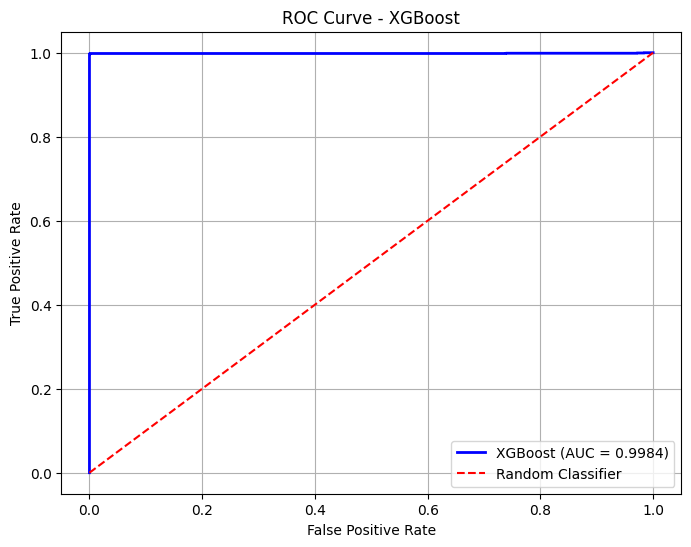

In [76]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         color='blue',
         linewidth=2,
         label=f'XGBoost (AUC = {roc_auc:.4f})')

plt.plot([0,1], [0,1],
         linestyle='--',
         color='red',
         label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

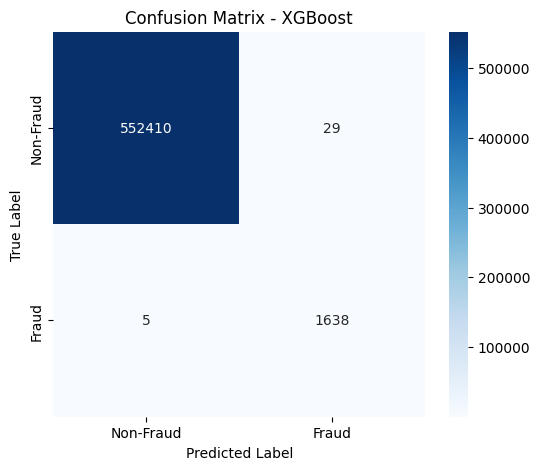

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")

plt.show()

## Precision-Recall Curve

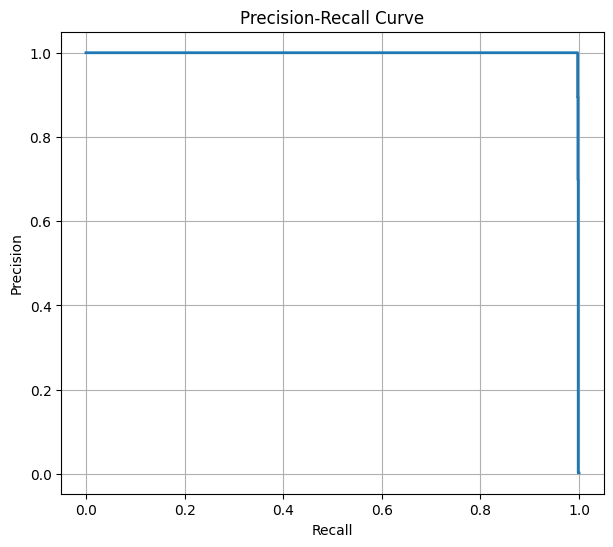

In [81]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(recall,
         precision,
         linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

## Feature Importance

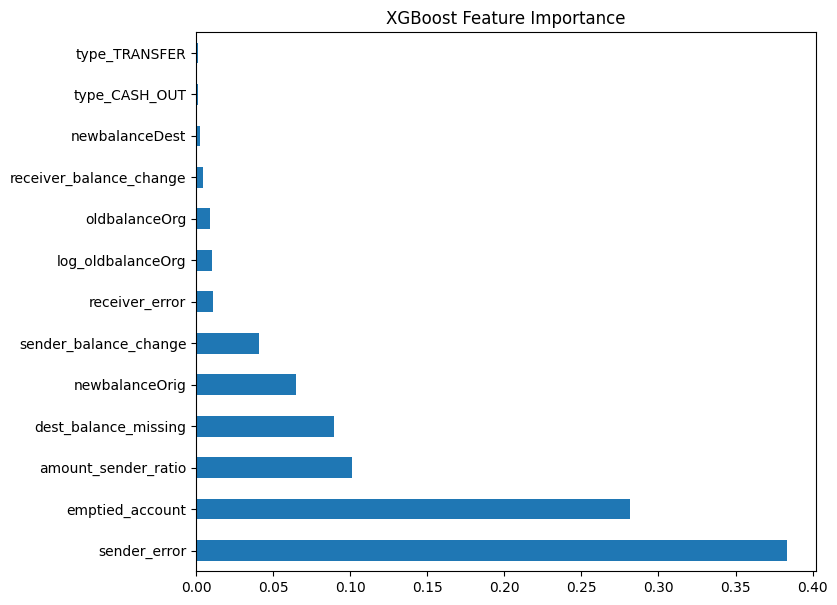

In [94]:
importance = pd.Series(
    loaded_model.feature_importances_,
    index=X_test.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,7))

importance.plot(kind='barh')

plt.title("XGBoost Feature Importance")

plt.show()

## Business Metrics

In [87]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"True Positives : {tp}")
print(f"False Positives: {fp}")
print(f"True Negatives : {tn}")
print(f"False Negatives: {fn}")

fraud_detection_rate = tp / (tp + fn)
false_alarm_rate = fp / (fp + tn)

print(f"\nFraud Detection Rate : {fraud_detection_rate:.4f}")
print(f"False Alarm Rate     : {false_alarm_rate:.4f}")

True Positives : 1638
False Positives: 29
True Negatives : 552410
False Negatives: 5

Fraud Detection Rate : 0.9970
False Alarm Rate     : 0.0001


## Threshold Optimization

In [90]:
threshold = 0.30

y_pred_custom = (y_prob >= threshold).astype(int)

In [92]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.97      1.00      0.98      1643

    accuracy                           1.00    554082
   macro avg       0.99      1.00      0.99    554082
weighted avg       1.00      1.00      1.00    554082

